In [246]:
# import knihoven
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat as uf
from scipy.optimize import curve_fit
from scipy import stats
from pathlib import Path

# path config
# cesta do Downloads funguje stejne na Windows i Linuxu
downloads_dir = Path.home() / "Downloads"

# ujistime se, ze slozka existuje (kdyby nahodou ne)
downloads_dir.mkdir(parents=True, exist_ok=True)

# ulozeni - Path se automaticky prevede na string se spravnymi lomitky
# output_path = downloads_dir / 'muj_graf.png'

In [247]:
# definice funkci

# nejistoty typu B pro digitalni pristroje
def unc_B_digital(reading, percent_reading, digits, resolution):    # vse musi byt ve spravnych jednotkach; funguje pouze pro jedny podminky zaroven
    """
    Vypocet nejistoty typu B pro digitalni mereni (ponechame krajni)

    reading : float nebo array
        namerena hodnota
    percent_reading : float
        % of reading
    digits : float
        pocet digitu
    resolution : float
        nejmensi dilek
    """

    max_error = abs(reading) * (percent_reading/100) + digits * resolution  # max_error -- krajni nejistota
    u_B = max_error

    return u_B

# funkce na Studentuv koeficient
def StudCoef(confidence, dof): 
    """
    Parametry
    confidence : float
        hladina spolehlivosti, typicke hodnoty 0.683, 0.9973;
    dof : 
        pocet stupnu volnosti, pro jednoduchou statistiku array.size-1
    Returns : float
    Studentuv koeficient pro danou hladinu spolehlivosti a pocet stupnu volnosti
    """
    alpha = 1 - confidence
    return stats.t.ppf(1 - alpha/2, dof)

# nejistota typu A 
def unc_A(data):
    """
    Výpočet nejistoty typu A
    data : list nebo numpy array
         měření
    return : float
        nejistota typu A
    """
    data = np.array(data)
    n = len(data)

    s = np.std(data, ddof=1)
    u_A = s / np.sqrt(n)
    
    return u_A

In [248]:
# nacteni google tabulek
sheet_id = '1UsP814IJrfRsE0t9Es3ti1vHPey5zNOwflnBbbTUxkY'
gid = '312593068'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df_impedance = pd.read_csv(url)

In [249]:
# impedance


Ri = df_impedance['Ri'].iloc[0]
odpor_u20 = np.array(df_impedance['odpor_U20'])*1e-3
odpor_i = odpor_u20 / Ri
odpor_um0 = np.array(df_impedance['odpor_UM0'])*1e-3
odpor_rr = odpor_um0 / odpor_i
unc_rr = unc_A(odpor_rr)
prumer_odpor_rr = uf(np.mean(odpor_rr), unc_rr)
print(f'RR = {odpor_rr}\nR_R = {prumer_odpor_rr:.1u}')

kond_u20 = np.array(df_impedance['kond_U20'])*1e-3
kond_i = kond_u20 / Ri
kond_um0 = np.array(df_impedance['kond_UM0'])
kond_z = kond_um0 / kond_i
kond_f = np.array(df_impedance['kond_f'])
kond_phi = np.array(df_impedance['kond_phiM2'])*(np.pi/180)
kond_c = -1/(2*np.pi*kond_f*kond_z*np.sin(kond_phi))
kond_rc = kond_z * np.cos(kond_phi)
prumer_kond_c = uf(np.mean(kond_c), unc_A(kond_c))
print(f'ZC = {kond_z},\nC  = {kond_c},\nRC = {kond_rc}\nC_C = {prumer_kond_c:.1u}')

civka_u20 = np.array(df_impedance['civka_U20'])*1e-3
civka_i = civka_u20 / Ri
civka_um0 = np.array(df_impedance['civka_UM0'])
civka_z = civka_um0 / civka_i
civka_f = np.array(df_impedance['civka_f'])
civka_phi = np.array(df_impedance['civka_phiM2'])*(np.pi/180)
civka_l = (civka_z*np.sin(civka_phi))/(2*np.pi*civka_f)
civka_rl = civka_z*np.cos(civka_phi)
prumer_civka_l = uf(np.mean(civka_l), unc_A(civka_l))
print(f'ZL = {civka_z},\nL  = {civka_l},\nRL = {civka_rl}\nL_L = {prumer_civka_l:.1u}')

RR = [19.59478127 19.59478127 19.6196319  19.6196319  19.63692072 19.6196319 ]
R_R = 19.614+/-0.007
ZC = [ 285.74757282  478.11441648  707.97297297  892.62978723 2362.78651685
 6783.48387097],
C  = [2.22807592e-07 2.21920301e-07 2.21924163e-07 2.22879104e-07
 2.24535480e-07 2.34630179e-07],
RC = [ 3.49097834e+00  2.92760645e-14 -4.94254361e+00 -6.23168089e+00
  1.64952277e+01  5.91963128e+01]
C_C = (2.25+/-0.02)e-07
ZL = [1735.33884298 1042.58706468  702.17449664  555.40425532  208.325
   69.62878788],
L  = [0.11045087 0.11059345 0.11028745 0.11043342 0.11037831 0.10954258],
RL = [36.34219469 23.65352051 17.1556524  18.41452716 10.53977424 10.53210757]
L_L = 0.1103+/-0.0002


In [250]:
# nacteni google tabulek
sheet_id = '1UsP814IJrfRsE0t9Es3ti1vHPey5zNOwflnBbbTUxkY'
gid = '800069381'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df_rezonance = pd.read_csv(url)

In [251]:
# rezonance
rez_f = np.array(df_rezonance['f'])
rez_um0 = np.array(df_rezonance['UM0'])*1e-3 # hodnoty vetsi nez 1000 byly namereny v rezimu 9.999 Volt
rez_u20 = np.array(df_rezonance['U20'])*1e-3
rez_phi = np.array(df_rezonance['phiM2'])*(np.pi/180)
rez_g = rez_u20/(Ri*rez_um0)
rez_phi_g = -rez_phi
print(f'G = {rez_g}\nphi_g = {rez_phi_g*180/np.pi}')


G = [0.02524489 0.02511677 0.02385618 0.02176169 0.02004446 0.01670771
 0.01356132 0.00879486 0.00454789 0.00395215 0.02484861 0.02340794
 0.02188513 0.01927909 0.01572516 0.01228075 0.00821277 0.00482853
 0.00412234]
phi_g = [ -0.2   7.8  19.2  31.1  38.3  49.   58.   70.1  80.1  81.5 -10.2 -21.6
 -29.6 -39.7 -51.2 -60.5 -70.7 -78.6 -80.2]


R = 39.60±0.02
L = 0.1109±0.0001
C = (2.224±0.003)×10⁻⁷
F = 9.02±0.01
Q = 17.83±0.02
alpha = 178.6±0.2


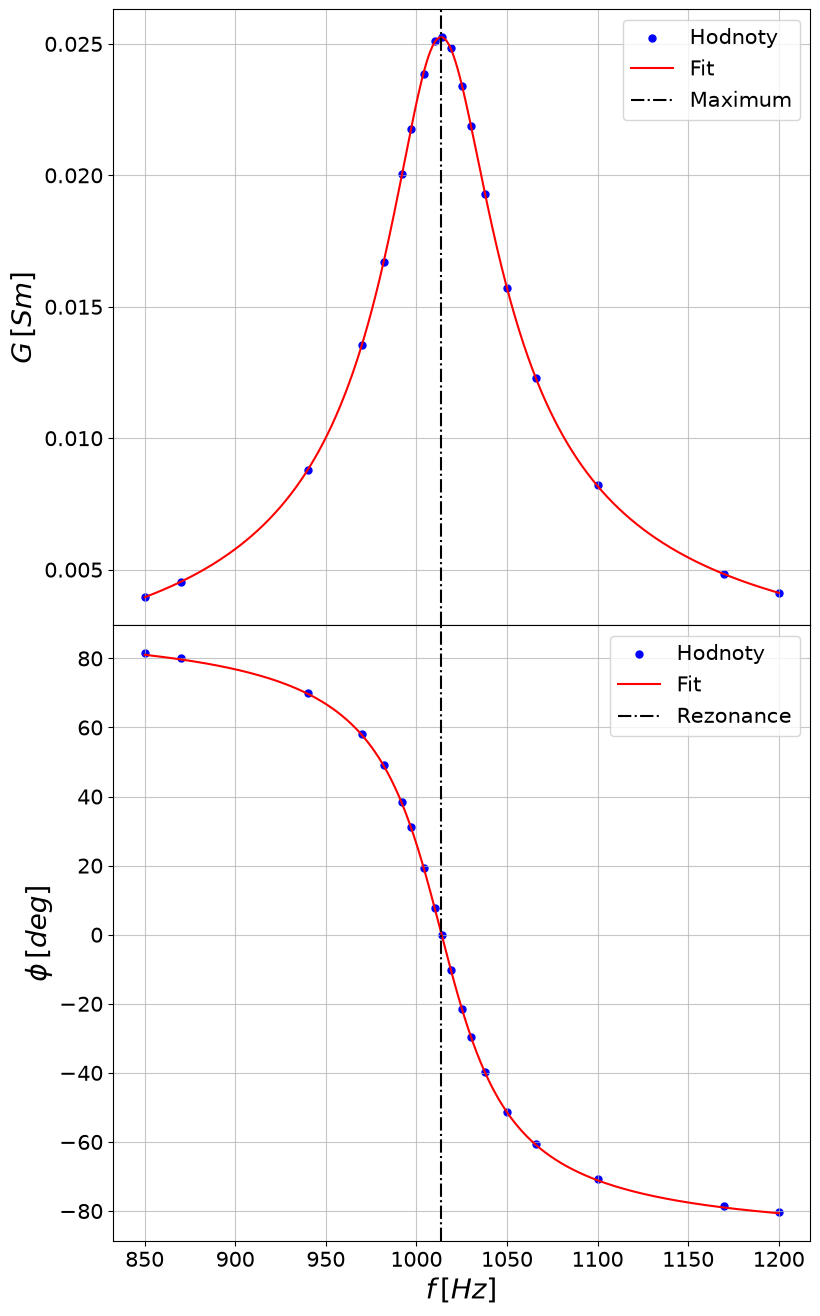

In [252]:
# fit a graf vodivosti abs(G)

def model_G(f, R, L, C):
    return 1/((R**2 + (2*np.pi*f*L - 1/(2*np.pi*f*C))**2)**0.5)
p0_G = [30, 113*1e-3, 217*1e-9]
popt_G, pcov_G = curve_fit(model_G, rez_f, rez_g, p0_G)
R, L, C = popt_G
unc_R, unc_L, unc_C = np.sqrt(np.diag(pcov_G))
R = uf(R, unc_R)
L = uf(L, unc_L)
C = uf(C, unc_C)
F = 1/L
Q = (1/R)*((L/C)**0.5)
alpha = R/(2*L)
print(f'R = {R:.1uPL}\nL = {L:.1uPL}\nC = {C:.1uPL}\nF = {F:.1uPL}\nQ = {Q:.1uPL}\nalpha = {alpha:.1uPL}')

def model_phi(f, R, L, C):
    return np.atan(((1/(2*np.pi*f*C))-(2*np.pi*f*L))/(R))
p0_phi = [30, 113*1e-3, 217*1e-9]
popt_phi, pcov_phi = curve_fit(model_phi, rez_f, rez_phi_g, p0_phi)

fig, ax = plt.subplots(2, 1, figsize=(9,16), sharex=True)
rez_x = 1013.82
ax[0].set_ylabel(fr"$G\,[Sm]$", fontsize=20)
ax[0].scatter(rez_f, rez_g, marker='.', s=100, label='Hodnoty', color='blue')
linspace_f = np.linspace(min(rez_f), max(rez_f), 1000)
ax[0].plot(linspace_f, model_G(linspace_f, *popt_G), label="Fit", color='red')
ax[0].axvline(x=rez_x, color='k', linestyle='-.', linewidth=1.5, label='Maximum')
ax[0].tick_params(labelsize=15)
ax[0].grid(True, alpha=0.7)
ax[0].legend(fontsize=15)

ax[1].set_xlabel(fr"$f\,[Hz]$", fontsize=20)
ax[1].set_ylabel(fr"$\phi\,[deg]$", fontsize=20)
ax[1].scatter(rez_f, rez_phi_g*(180/np.pi), marker='.', s=100, label='Hodnoty', color='blue')
ax[1].plot(linspace_f, model_phi(linspace_f, *popt_phi)*(180/np.pi), label="Fit", color='red')
ax[1].axvline(x=rez_x, color='k', linestyle='-.', linewidth=1.5, label='Rezonance')
ax[1].tick_params(labelsize=15)
ax[1].grid(True, alpha=0.7)
ax[1].legend(fontsize=15)
fig.subplots_adjust(hspace=0.0)
path_vodivost = downloads_dir / 'vodivost.png'
plt.savefig(path_vodivost, dpi=300, bbox_inches='tight')

In [253]:
# nacteni google tabulek
sheet_id = '1UsP814IJrfRsE0t9Es3ti1vHPey5zNOwflnBbbTUxkY'
gid = '1913907669'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df_prechod = pd.read_csv(url)

alpha = 445±1
omegad = 6351±1



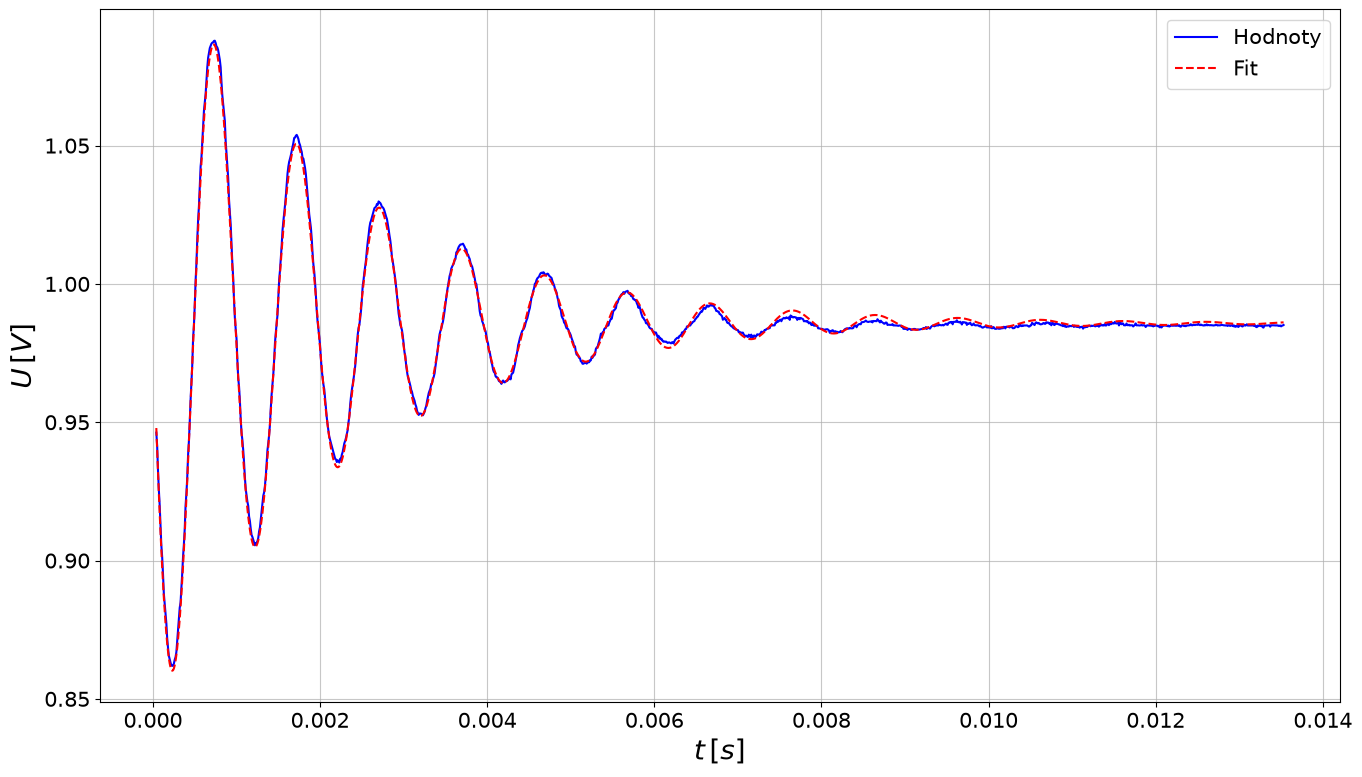

In [254]:
# prechodovy jev

podcas = np.array(df_prechod['podcas'].iloc[150:1500])
pod1 = np.array(df_prechod['pod1'].iloc[150:1500])

def model_pod(t, Uc, alpha, omegad, phi, Uf):
    return Uc*np.exp(-alpha*t)*np.cos(omegad*t + phi) + Uf
p0_pod = [-0.1, 445, 6351, -1, -0.98]
popt_pod, pcov_pod = curve_fit(model_pod, podcas, pod1, p0_pod)
Uc, alpha, omegad, phi, Uf = popt_pod
_, alpha_u, omegad_u, _,_ = np.sqrt(np.diag(pcov_pod))
alpha = uf(alpha, alpha_u)
omegad = uf(omegad, omegad_u)
print(f'alpha = {alpha:.1uPL}\nomegad = {omegad:.1uPL}\n')


fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylabel(fr"$U\,[V]$", fontsize=20)
ax.set_xlabel(fr"$t\,[s]$", fontsize=20)
ax.plot(podcas, pod1, label='Hodnoty', color='blue')
ax.plot(podcas, model_pod(podcas, *popt_pod), label='Fit', color='red', ls='--')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_pod = downloads_dir / 'podkriticke.png'
plt.savefig(path_pod, dpi=300, bbox_inches='tight')

[ 2.34406530e-01 -2.26849803e+03 -8.19868413e+03  9.86082745e-01]


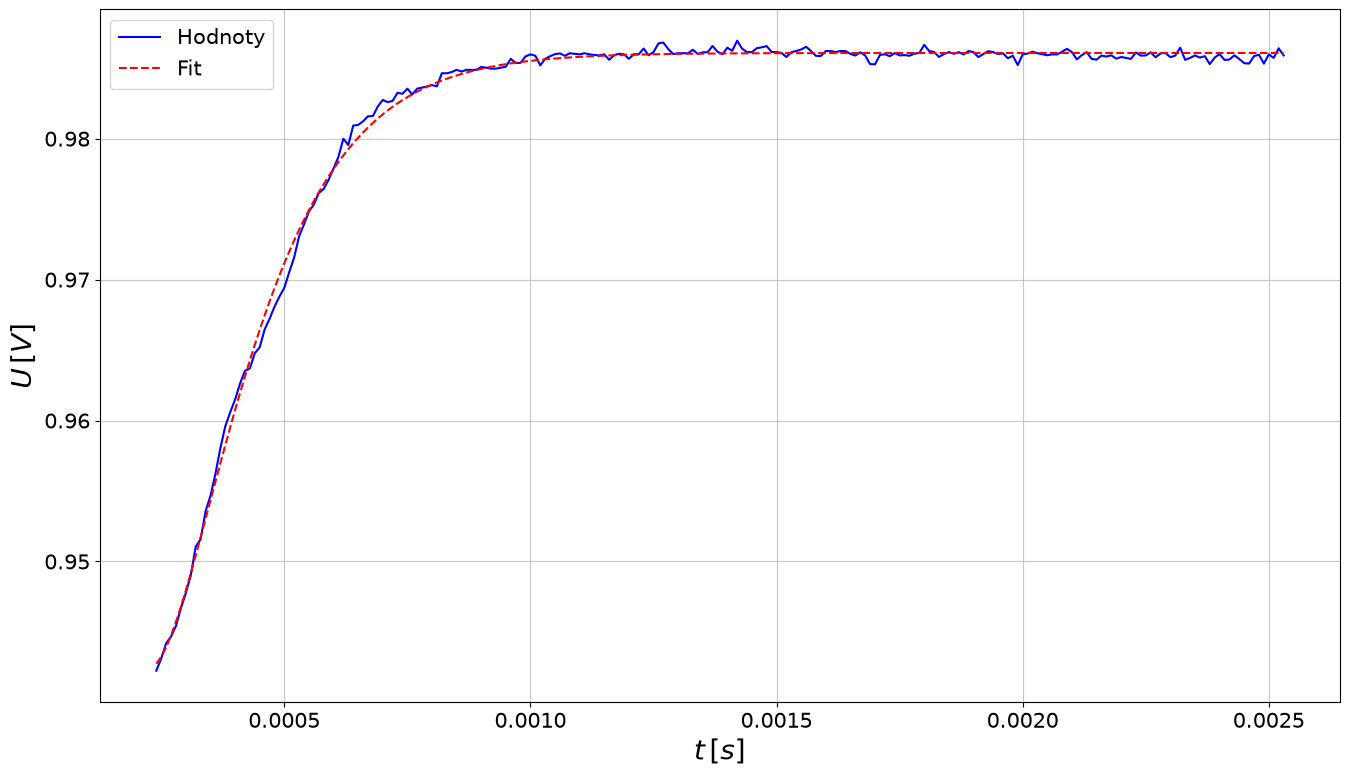

In [271]:
# kriticke

kritcas = np.array(df_prechod['kritcas'].iloc[170:400])
krit1 = np.array(df_prechod['krit1'].iloc[170:400])

def model_krit(t, Uc6, Uc7, lambd, Uf):
    return (Uc6 + Uc7*t)*np.exp(lambd*t)+Uf
p0_krit = [0.2, -2182, -8118, 0.98]
popt_krit, pcov_krit = curve_fit(model_krit, kritcas, krit1, p0_krit)
print(popt_krit)

fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylabel(fr"$U\,[V]$", fontsize=20)
ax.set_xlabel(fr"$t\,[s]$", fontsize=20)
ax.plot(kritcas, krit1, label='Hodnoty', color='blue')
ax.plot(kritcas, model_krit(kritcas, *popt_krit), label='Fit', color='red', ls='--')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_krit = downloads_dir / 'kriticke.png'
plt.savefig(path_krit, dpi=300, bbox_inches='tight')

[-3.62298169e-02 -2.00523863e+03  9.85057989e-01]


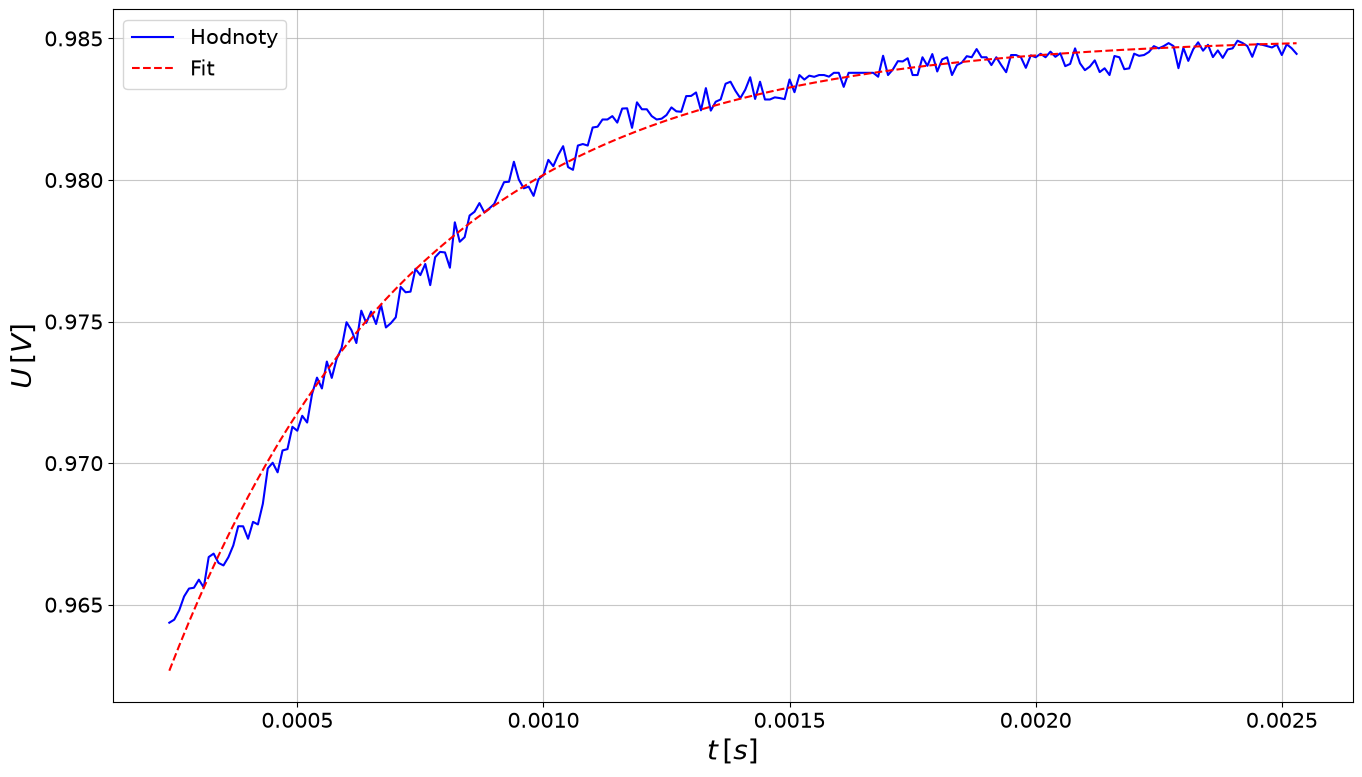

In [272]:
# nadkriticke

nadcas = np.array(df_prechod['nadcas'].iloc[170:400])
nad1 = np.array(df_prechod['nad1'].iloc[170:400])

def model_nad(t, Uc1, lambd1, Uf):
    return Uc1*np.exp(lambd1*t)  + Uf
p0_nad = [1, -1000, 1]
popt_nad, pcov_nad = curve_fit(model_nad, nadcas, nad1, p0_nad)
print(popt_nad)

fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylabel(fr"$U\,[V]$", fontsize=20)
ax.set_xlabel(fr"$t\,[s]$", fontsize=20)
ax.plot(nadcas, nad1, label='Hodnoty', color='blue')
ax.plot(nadcas, model_nad(nadcas, *popt_nad), label='Fit', color='red', ls='--')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_nad = downloads_dir / 'nadkriticke.png'
plt.savefig(path_nad, dpi=300, bbox_inches='tight')

λ = -1855+/-29, B = -3.49+/-0.04
R = 2631+/-34


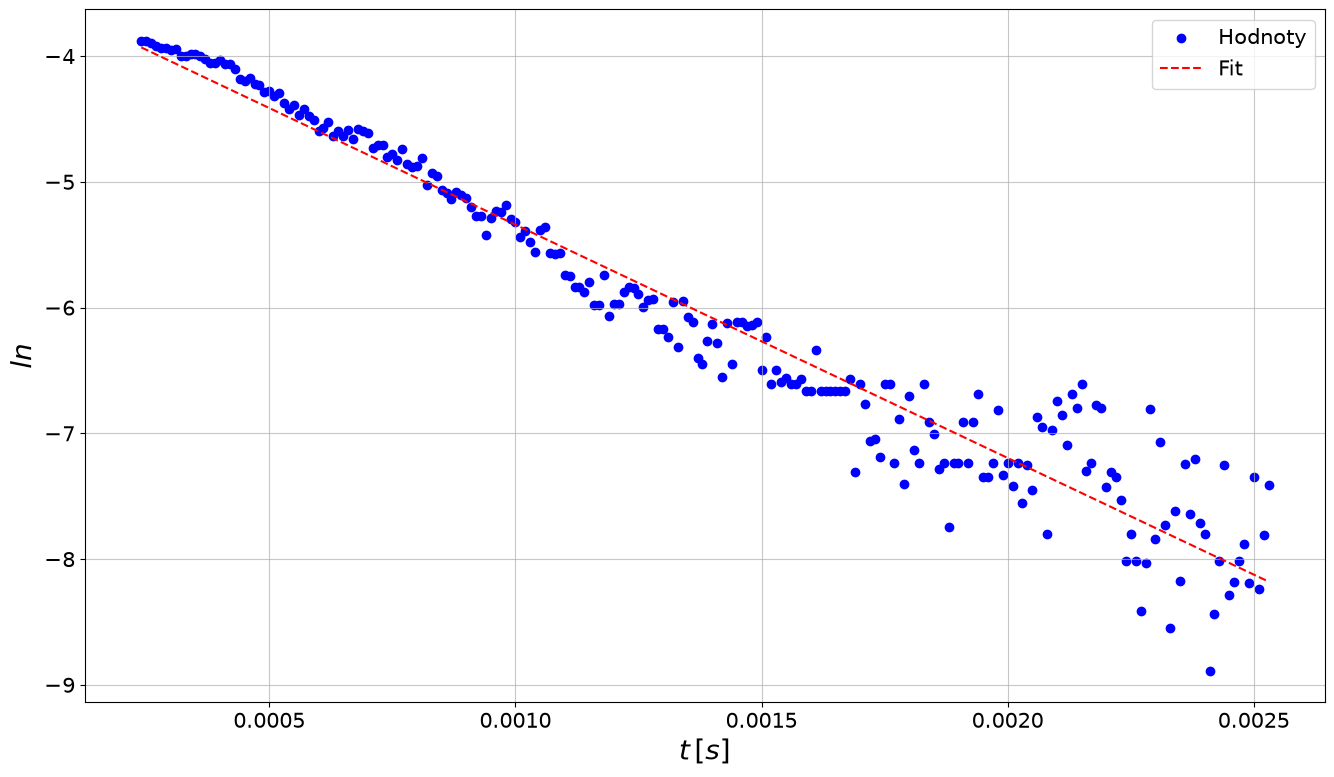

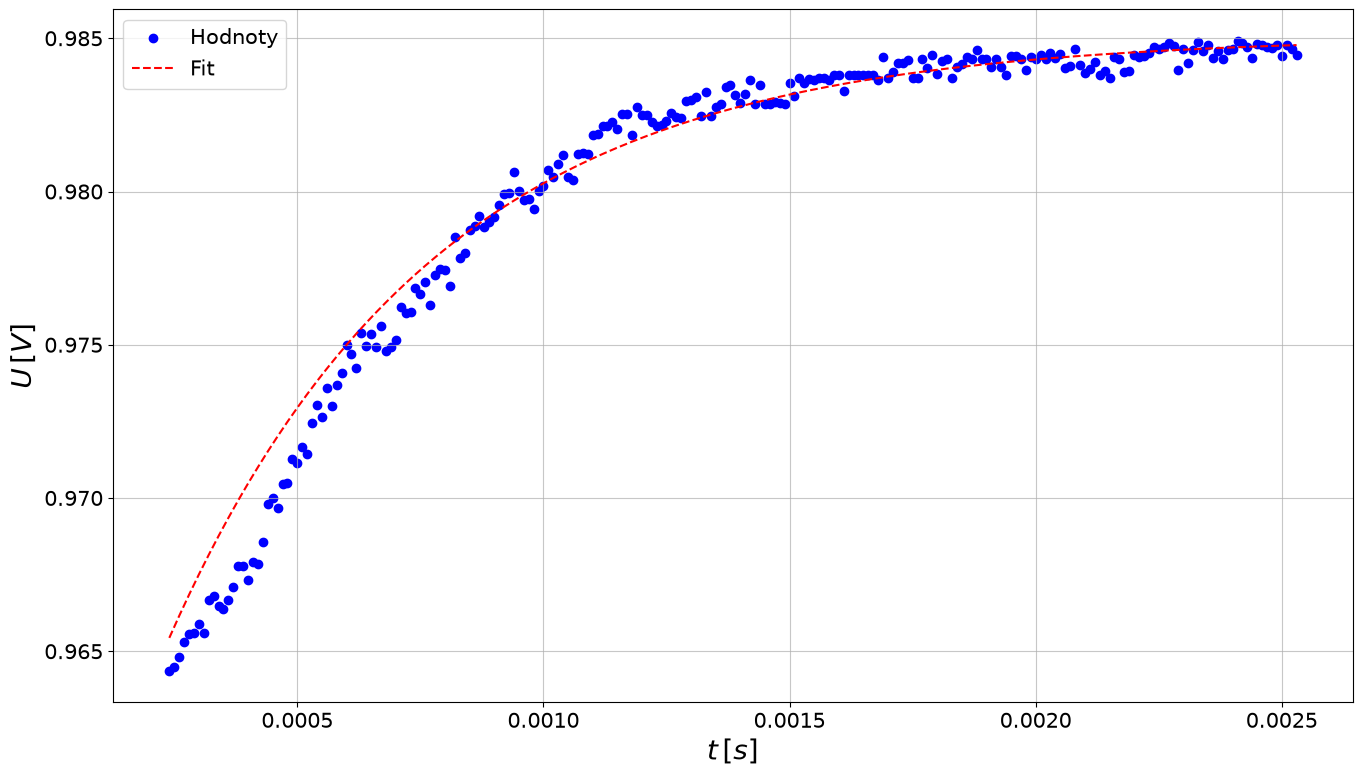

In [284]:
logUc = np.log(-nad1+9.85057989e-01)
def func(t, A, B):
    return A*t+B
popt, pcov = curve_fit(func, nadcas, logUc)
A= uf(popt[0], np.sqrt(pcov[0,0]))
B= uf(popt[1], np.sqrt(pcov[1,1]))
print(f"λ = {A}, B = {B}")
R=-(L)*((2*np.pi*rez_x)**2+A**2)/A
print(f"R = {R}")

fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylabel(fr"$ln$", fontsize=20)
ax.set_xlabel(fr"$t\,[s]$", fontsize=20)
ax.scatter(nadcas, logUc, label='Hodnoty', color='blue')
ax.plot(nadcas, func(nadcas, *popt), label='Fit', color='red', ls='--')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_ln = downloads_dir / 'nadkriticke_ln.png'
plt.savefig(path_ln, dpi=300, bbox_inches='tight')


fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylabel(fr"$U\,[V]$", fontsize=20)
ax.set_xlabel(fr"$t\,[s]$", fontsize=20)
ax.scatter(nadcas, nad1, label='Hodnoty', color='blue')
ax.plot(nadcas, 9.85057989e-01 - np.exp(func(nadcas, *popt)), label='Fit', color='red', ls='--')
ax.tick_params(labelsize=15)
ax.grid(True, alpha=0.7)
ax.legend(fontsize=15)
path_e = downloads_dir / 'nadkriticke_e.png'
plt.savefig(path_e, dpi=300, bbox_inches='tight')